# Otimização de Descarregamento de Balsa

Este trabalho visa encontrar a solução ótima para o problema de descarregamento e locomoção de containers em portos.

Os objetivos principais são:
- Garantir um descarrecamento mantendo a estabilidade da embarcação
- Garantir que os containers sejam retirados na melhor ordem para sua locomoção
- Garantir a melhor rota para a entrega dos containers

### Bibliotecas

In [52]:
import numpy as np
import random
import copy
import matplotlib.pyplot as plt

### Constantes

In [53]:
num_individuos = 100
num_bits = 16
num_containers = 20

# Valores a serem modificados
fator_CL = 3.8
tam_barco = 50

barco = np.array(
    [[ # Primeiro andar
        [1, 1, 1, 1], 
        [1, 1, 1, 1], 
        [1, 1, 1, 1], 
        [1, 1, 1, 1]
    ],
    [ # Segundo andar
        [0, 0, 0, 0], 
        [0, 1, 1, 0], 
        [0, 1, 1, 0], 
        [0, 0, 0, 0]
    ]]
)


## AG

In [54]:
class Argo:
    def __init__(
        self,
        barco: list,
        num_containers: int = 20,
        tam_populacao: int = 100,
        p_mutacao: float = 0.1, # Evitar minimos locais
        p_crossover: float = 0.8,
        num_geracoes: int = 100,
    ):
        self.barco = barco
        self.num_containers = num_containers
        self.tam_populacao = tam_populacao
        self.p_mutacao = p_mutacao
        self.p_crossover = p_crossover
        self.num_geracoes = num_geracoes
        self.tam_cromossomos = self.num_containers
        self.populacao = [self.gerar_cromossomo() for _ in range(self.tam_populacao)]
        # Variáveis para armazenar o histórico e o "Melhor de Sempre"
        self.historico_melhor_individuo = []
        self.historico_media = []
        self.pier = np.zeros((2, 5, 2))

    def garra(self, garra_pos_atual: tuple[int, int], alvo_y: int, alvo_x: int):
        """Reproz o movimento da garra que pega os containers"""

        movimentos =  abs(garra_pos_atual[0] - alvo_y) + abs(garra_pos_atual[1] - alvo_x)
        nova_posicao = (alvo_y, alvo_x)
        return movimentos, nova_posicao
    
    def verificar_container_abaixo(self, matriz: np.ndarray, y: int, x: int, acao: str):
        """Verifica se existe um container abaixo"""

        match acao:
            case 'pegar':
                for z in range(matriz.shape[0]-1, -1, -1):
                    if matriz[z, y, x] == 1:
                        return z
                return -1
            case 'largar':
                for z in range(matriz.shape[0]):
                    if matriz[z, y, x] == 0:
                        return z
                return -1
            case _:
                return -1 
        
    def calcular_estabilidade(self, barco_aux: np.ndarray, peso_total_barco: float):
        """Calcula o centro de massa e retorna a penalidade caso esteja instável."""
        if peso_total_barco > 0:
            pesos_x = np.sum(barco_aux, axis=(0, 1))
            centro_massa_x = np.sum(pesos_x * np.arange(4)) / peso_total_barco

            if abs(centro_massa_x - 1.5) > 1.0:
                return 50.0 # penalidade
        
        return 0.0
    
    def funcao_fitness(self, cromossomo: np.ndarray):
        """
        Penaliza movimentos inválidos e instabilidade.
        No entanto, recompensa menor custo na distância percorrida.
        """

        barco_aux = copy.deepcopy(self.barco)

        movimentos_totais = 0
        penalidade = 0.0
        posicao_garra = (0, 0)
        peso_total_barco = int(np.sum(barco_aux))

        for acao in cromossomo:
            barco_y, barco_x, pier_y, pier_x = acao

            pegar_z = self.verificar_container_abaixo(barco_aux, barco_y, barco_x, 'pegar')

            if pegar_z == -1:
                penalidade += 500.0 # modificar conforme necessidade
                continue

            barco_aux[pegar_z, barco_y, barco_x] = 0

            movimento, posicao_garra = self.garra(posicao_garra, barco_y, barco_x)
            movimentos_totais += movimento

            peso_total_barco -= 1
            penalidade += self.calcular_estabilidade(barco_aux, peso_total_barco)

            largar_z = self.verificar_container_abaixo(self.pier, pier_y, pier_x, 'largar')

            if largar_z == -1:
                penalidade += 500.0
                continue

            self.pier[largar_z, pier_y, pier_x] = 1

            movimento, posicao_garra = self.garra(posicao_garra, pier_y, pier_x)
            movimentos_totais += movimento

        containers_restantes = int(np.sum(barco_aux))
        penalidade += containers_restantes * 1000.0

        custo_total = movimentos_totais + penalidade
        return 10000.0 / (custo_total + 1.0)
    
    def decodificar(self, cromossomo: list):
        """Decodifica o cromossomo para obter as localizações iniciais e finais no descarregamento."""

        inicial_x = cromossomo[0]
        inicial_y = cromossomo[1]
        inicial_z = cromossomo[2]
        final_x = cromossomo[3]
        final_y = cromossomo[4]
        final_z = cromossomo[5]

        return inicial_x, inicial_y, inicial_z, final_x, final_y, final_z 

    def gerar_cromossomo(self):
        """
        Gera cromossomos com coordenadas aleatórios de posicionamento barco -> pier.
        """
        cromossomo = []

        for _ in range(self.tam_cromossomos):
            barco_y, barco_x = random.randint(0, 3), random.randint(0,3)
            pier_y, pier_x = random.randint(0, 4), random.randint(0,1)
            cromossomo.append([barco_y, barco_x, pier_y, pier_x])
        return np.array(cromossomo)

    def inicializar_otimização(self):
        """Inicializa otimização."""
        for gen in range(self.num_geracoes):
            fitnesses = [self.funcao_fitness(individuo) for individuo in self.populacao]

            melhor_idx = int(np.argmax(fitnesses))
            melhor_fitness = fitnesses[melhor_idx]
            melhor_individuo = self.populacao[melhor_idx].copy()

            print(f"Geração {gen} | Melhor Fitness: {melhor_fitness:.4f}")

            self.historico_melhor_individuo.append(melhor_fitness)
            self.historico_media.append(float(np.mean(fitnesses)))

            nova_população = []
            nova_população.append(melhor_individuo) # Elitismo

            while len(nova_população) < self.tam_populacao:
                pai = self.torneio(fitnesses)
                mae = self.torneio(fitnesses)

                primogenito, ultimogênito = self.crossover(pai, mae)

                self.mutar(primogenito)
                self.mutar(ultimogênito)

                nova_população.append(primogenito)

                if len(nova_população) < self.tam_populacao:
                    nova_população.append(ultimogênito)
            self.populacao = nova_população

        return self.historico_melhor_individuo, self.historico_media, self.populacao[0]

    def torneio(self, fitnesses: list[float], num_competidores: int = 3):
        """Seleciona por torneio. Minimizar perda de diversidade"""
        participantes = random.sample(range(self.tam_populacao), num_competidores)
        ganhador = max(participantes, key=lambda idx: fitnesses[idx])
        return self.populacao[ganhador].copy()

    def crossover(self, pai: np.ndarray, mae: np.ndarray):
        """Crossover de 2 pontos na sequência de ações"""
        if np.random.rand() < self.p_crossover:
            ponto = np.random.randint(2, self.tam_cromossomos - 1)
            primogenito = np.concatenate([pai[:ponto], mae[ponto:]])
            ultimogênito = np.concatenate([mae[:ponto], pai[ponto:]])
            return primogenito, ultimogênito
        return pai.copy(), mae.copy()

    def mutar(self, individuo: np.ndarray):
        """Altera uma coordenada aleatoriamente."""
        for i in range(self.tam_cromossomos):
            if np.random.rand() < self.p_mutacao:
                individuo[i][0] = random.randint(0, 3)
                individuo[i][1] = random.randint(0, 3)
            else:
                individuo[i][2] = random.randint(0, 4)
                individuo[i][3] = random.randint(0, 1)

    def visualizar_resultado_final(self, melhor_cromossomo: np.ndarray) -> None:
        """Simula a melhor sequência de ações e imprime como os containers ficaram empilhados."""
        barco_sim: np.ndarray = copy.deepcopy(self.barco)
        
        for acao in melhor_cromossomo:
            b_y, b_x, p_y, p_x = acao
            
            z_pegou = self.verificar_container_abaixo(barco_sim, b_y, b_x, "pegar")
            if z_pegou != -1:
                barco_sim[z_pegou, b_y, b_x] = 0 
                
                z_largou = self.verificar_container_abaixo(self.pier, p_y, p_x, "largar")
                if z_largou != -1:
                    self.pier[z_largou, p_y, p_x] = 1

        print("\n" + "="*40)
        print("RESULTADO FINAL DO DESCARREGAMENTO")
        print("="*40)
        
        for z in range(self.pier.shape[0]-1, -1, -1):
            print(f"\nNÍVEL Z = {z} (Andar {z+1}):")
            print("  Col 0  Col 1")
            for y in range(self.pier.shape[1]):
                linha = self.pier[z, y]
                visual = [" [X] " if val == 1 else " [ ] " for val in linha]
                print(f"L{y}:" + "".join(visual))
                
        print("\n" + "-"*50)
        containers_restantes = int(np.sum(barco_sim))
        if containers_restantes == 0:
            print("SUCESSO: Todos os containers foram descarregados!")
        else:
            print(f"AVISO: Ficaram {containers_restantes} containers no barco.")
        print("="*50 + "\n")

## Teste

In [55]:
print("Iniciando Algoritmo Genético Argo...\n")
argo_ag: Argo = Argo(barco=barco, num_geracoes=150, tam_populacao=100)

melhor_hist: list[float]
media_hist: list[float]
melhor_hist, media_hist, melhor_individuo = argo_ag.inicializar_otimização()

Iniciando Algoritmo Genético Argo...

Geração 0 | Melhor Fitness: 0.9459
Geração 1 | Melhor Fitness: 0.7672
Geração 2 | Melhor Fitness: 0.7672
Geração 3 | Melhor Fitness: 0.7672
Geração 4 | Melhor Fitness: 0.7672
Geração 5 | Melhor Fitness: 0.7672
Geração 6 | Melhor Fitness: 0.8306
Geração 7 | Melhor Fitness: 0.8306
Geração 8 | Melhor Fitness: 0.8308
Geração 9 | Melhor Fitness: 0.8308
Geração 10 | Melhor Fitness: 0.8308
Geração 11 | Melhor Fitness: 0.8308
Geração 12 | Melhor Fitness: 0.8308
Geração 13 | Melhor Fitness: 0.8308
Geração 14 | Melhor Fitness: 0.9051
Geração 15 | Melhor Fitness: 0.9051
Geração 16 | Melhor Fitness: 0.9051
Geração 17 | Melhor Fitness: 0.9051
Geração 18 | Melhor Fitness: 0.9051
Geração 19 | Melhor Fitness: 0.9051
Geração 20 | Melhor Fitness: 0.9051
Geração 21 | Melhor Fitness: 0.9051
Geração 22 | Melhor Fitness: 0.9051
Geração 23 | Melhor Fitness: 0.9051
Geração 24 | Melhor Fitness: 0.9051
Geração 25 | Melhor Fitness: 0.9051
Geração 26 | Melhor Fitness: 0.9051


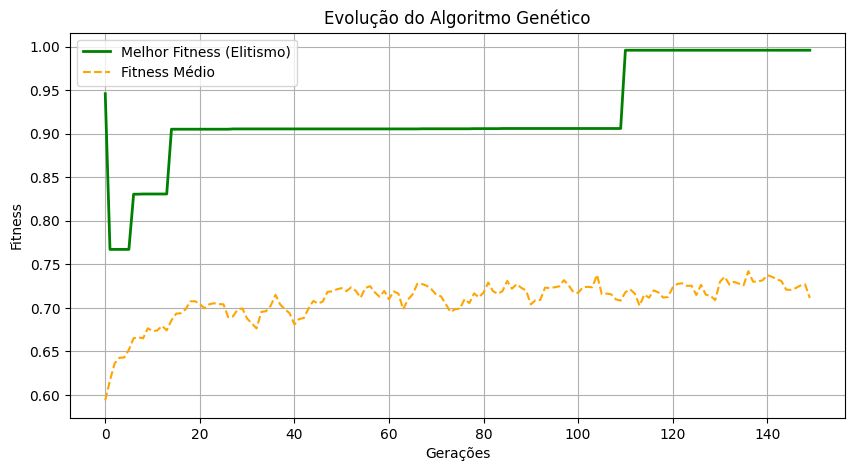

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(melhor_hist, label="Melhor Fitness (Elitismo)", color='green', linewidth=2)
plt.plot(media_hist, label="Fitness Médio", color='orange', linestyle='--')
plt.title("Evolução do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
argo_ag.visualizar_resultado_final(melhor_individuo)


RESULTADO FINAL DO DESCARREGAMENTO

NÍVEL Z = 1 (Andar 2):
  Col 0  Col 1
L0: [X]  [X] 
L1: [X]  [X] 
L2: [X]  [X] 
L3: [X]  [X] 
L4: [X]  [X] 

NÍVEL Z = 0 (Andar 1):
  Col 0  Col 1
L0: [X]  [X] 
L1: [X]  [X] 
L2: [X]  [X] 
L3: [X]  [X] 
L4: [X]  [X] 

--------------------------------------------------
SUCESSO: Todos os containers foram descarregados!



## Resultados